In [1]:
import pandas as pd

In [2]:
filename = "../data/notion/pressure_05_04_26.csv"
df = pd.read_csv(filename)

In [3]:
# Set correct dates
df.Date = pd.to_datetime(df.Date)
df

,Date,Hour,SYS,DIA,PUL,Notes
0,2026-01-08,10:00:00,117,59,62,NaN
1,2026-01-09,10:17:00,115,58,66,NaN
2,2026-01-10,08:41:00,124,67,61,NaN
3,2026-01-11,08:46:00,113,62,64,NaN
4,2026-01-12,08:11:00,101,65,64,NaN
5,2026-01-14,08:27:00,106,67,86,NaN
6,2026-01-26,13:25:00,97,60,76,NaN
7,2026-01-27,09:07:00,119,62,78,NaN
8,2026-01-28,09:33:00,103,58,83,NaN
9,2026-01-29,08:08:00,111,67,74,NaN


In [7]:
# Add missing dates as NaN
# use date as index
df = df.reset_index()
df = df.set_index("Date")

# create all dates between min and max
full_dates = pd.date_range(df.index.min(), df.index.max(), freq="D")

# reindex to include missing dates
df_full = df.reindex(full_dates)

# reset index to convert Date back to a column
df_full = df_full.reset_index()
df_full.rename(columns={"index": "Date"}, inplace=True)

df_full


,Date,Hour,SYS,DIA,PUL,Notes
0,2026-01-08,10:00:00,117.0,59.0,62.0,NaN
1,2026-01-09,10:17:00,115.0,58.0,66.0,NaN
2,2026-01-10,08:41:00,124.0,67.0,61.0,NaN
3,2026-01-11,08:46:00,113.0,62.0,64.0,NaN
4,2026-01-12,08:11:00,101.0,65.0,64.0,NaN
...,...,...,...,...,...,...
83,2026-04-01,07:33,117.0,62.0,78.0,NaN
84,2026-04-02,06:36,136.0,59.0,74.0,NaN
85,2026-04-03,10:20,110.0,70.0,82.0,"kawa, drzemka"
86,2026-04-04,12:46,109.0,64.0,91.0,drzemka


In [8]:
import os

output_dir = '../data/processed_data'
output_path = os.path.join(output_dir, 'pressure_05_04_26_processed.csv')
df_full.to_csv(output_path, index=False)

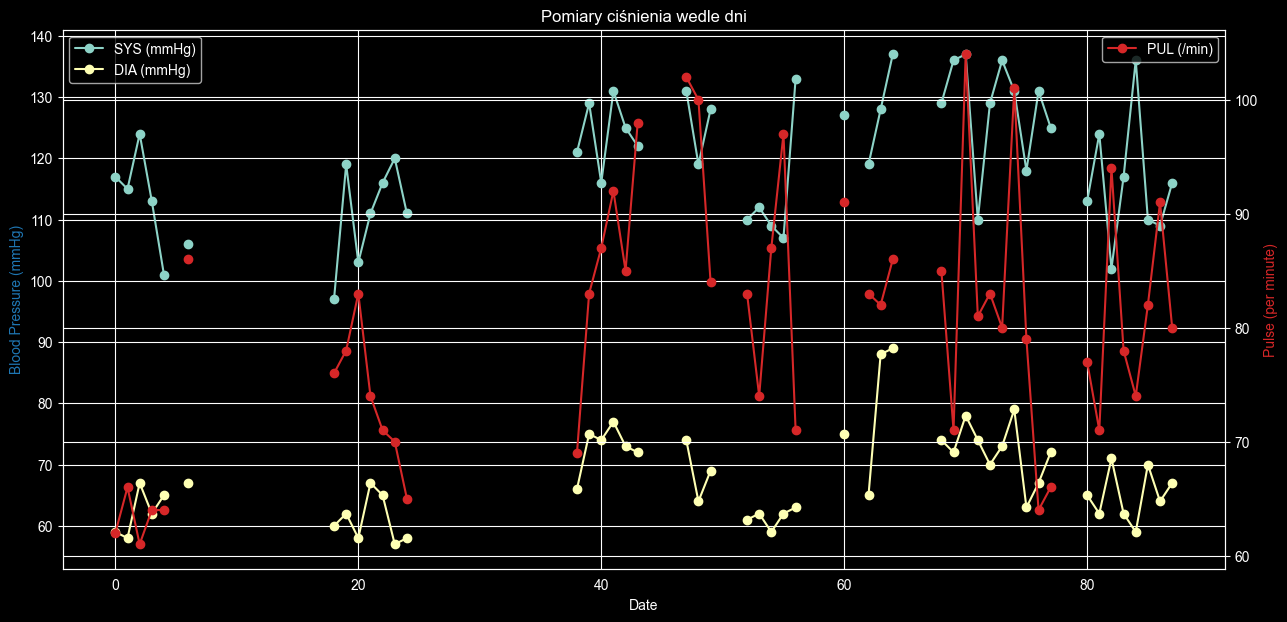

In [9]:
# Graphs
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 7))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Blood Pressure (mmHg)', color=color)
ax1.plot(df_full.index, df_full["SYS"], marker="o", label="SYS (mmHg)")
ax1.plot(df_full.index, df_full["DIA"], marker="o", label="DIA (mmHg)")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Pulse (per minute)', color=color)
ax2.plot(df_full.index, df_full["PUL"], marker="o", label="PUL (/min)", color=color)
ax2.legend(loc='upper right')

plt.title("Pomiary ciśnienia wedle dni")
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()